# Time-Series Regression Case Study

In [4]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import statsmodels.api as sm

from IPython.display import display
from scipy import stats
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.multitest import multipletests
from statsmodels.tsa.stattools import acf

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")


## 1. Load data and perform a minimal global audit

In [62]:
path = "time_series_regression_case_intermediate_signal_v2.csv"
df_raw = pd.read_csv(path, parse_dates=["date"])

print("Raw shape:", df_raw.shape)
print("Date range:", df_raw["date"].min(), "to", df_raw["date"].max())
print("Duplicate rows:", int(df_raw.duplicated().sum()))
print("Missing values by column:")
display(df_raw.isna().sum().to_frame("missing_count").T)
print("\nDtypes:")
display(df_raw.dtypes.astype(str).to_frame("dtype").T)

Raw shape: (1329, 8)
Date range: 2020-01-01 00:00:00 to 2024-12-31 00:00:00
Duplicate rows: 24
Missing values by column:


,date,return_1d,lag_return,momentum_5d,momentum_20d,rolling_volatility,macro_signal,vol_regime
missing_count,0,0,0,0,0,0,0,0



Dtypes:


,date,return_1d,lag_return,momentum_5d,momentum_20d,rolling_volatility,macro_signal,vol_regime
dtype,datetime64[us],float64,float64,float64,float64,float64,float64,float64


In [53]:
summary_table = pd.DataFrame({
    "min": df_raw.drop(columns=["date"]).min(numeric_only=True),
    "max": df_raw.drop(columns=["date"]).max(numeric_only=True),
    "mean": df_raw.drop(columns=["date"]).mean(numeric_only=True),
    "std": df_raw.drop(columns=["date"]).std(numeric_only=True),
})
display(summary_table)

,min,max,mean,std
return_1d,-0.131884,0.117931,0.000579,0.034793
lag_return,-0.131884,0.117931,0.000847,0.034676
momentum_5d,-0.066929,0.067442,0.000779,0.016466
momentum_20d,-0.031299,0.038437,0.000752,0.010567
rolling_volatility,0.015000,0.053556,0.032399,0.007095
macro_signal,-2.263512,2.379838,-0.005823,1.002086
vol_regime,0.012000,0.024000,0.015837,0.005599



***To be noted***: Slight postivie drift : 0.05% daily --> will need to compare strat with a simple "hold" benchmark


I will perform an intentionally minimal and global cleaning, avoiding the use any predictive structure:
- Sorting chronologically 
- Dropping exact duplicates
- Winsorizing return_1d at 1% / 99/ 
- Leaving imputation for later, through pipeline or causal methods to avoid leakage 

In [54]:
df = df_raw.sort_values("date").drop_duplicates().reset_index(drop=True).copy()
df_pre_winsor = df.copy()
ret_lo, ret_hi = df["return_1d"].quantile([0.01, 0.99])
df["return_1d"] = df["return_1d"].clip(ret_lo, ret_hi)
print("Post-cleaning shape:", df.shape)

Post-cleaning shape: (1305, 8)


## 2. Define the prediction target

In [55]:
# Shifting returns to avoid leakage 

df["target_return_next_day"] = df["return_1d"].shift(-1)
df = df.iloc[:-1].reset_index(drop=True).copy()
df[["date", "return_1d", "target_return_next_day"]].head()

,date,return_1d,target_return_next_day
0,2020-01-01,-0.012272,-0.050325
1,2020-01-02,-0.050325,-0.010261
2,2020-01-03,-0.010261,-0.005310
3,2020-01-06,-0.005310,-0.006043
4,2020-01-07,-0.006043,0.021259


## 3. Reserve a final holdout before detailed EDA

In [56]:
holdout_frac = 0.20
holdout_size = int(len(df) * holdout_frac)

dev_df = df.iloc[:-holdout_size].copy()
holdout_df = df.iloc[-holdout_size:].copy()

display(pd.DataFrame({
    "sample": ["development", "final_holdout"],
    "rows": [len(dev_df), len(holdout_df)],
    "start_date": [dev_df["date"].min(), holdout_df["date"].min()],
    "end_date": [dev_df["date"].max(), holdout_df["date"].max()],
}))

,sample,rows,start_date,end_date
0,development,1044,2020-01-01,2024-01-01
1,final_holdout,260,2024-01-02,2024-12-30


## 4. EDA on the development sample only

### 4.1 Existing features and target

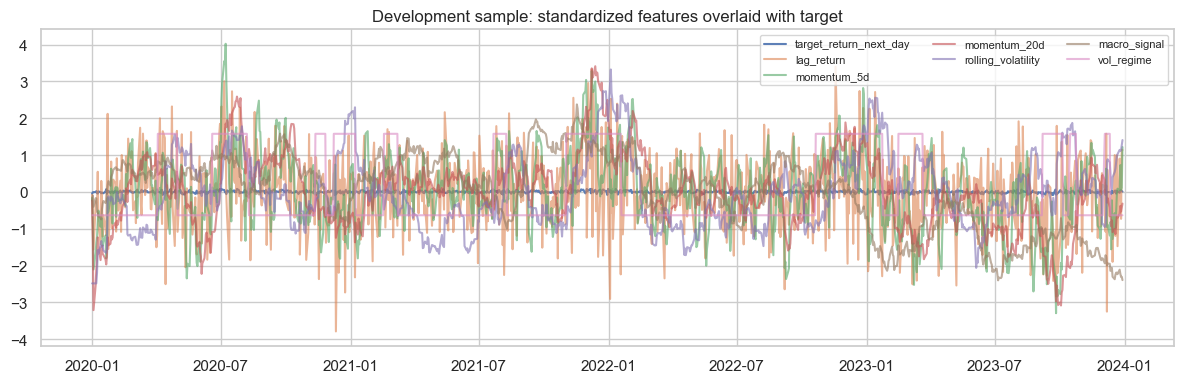

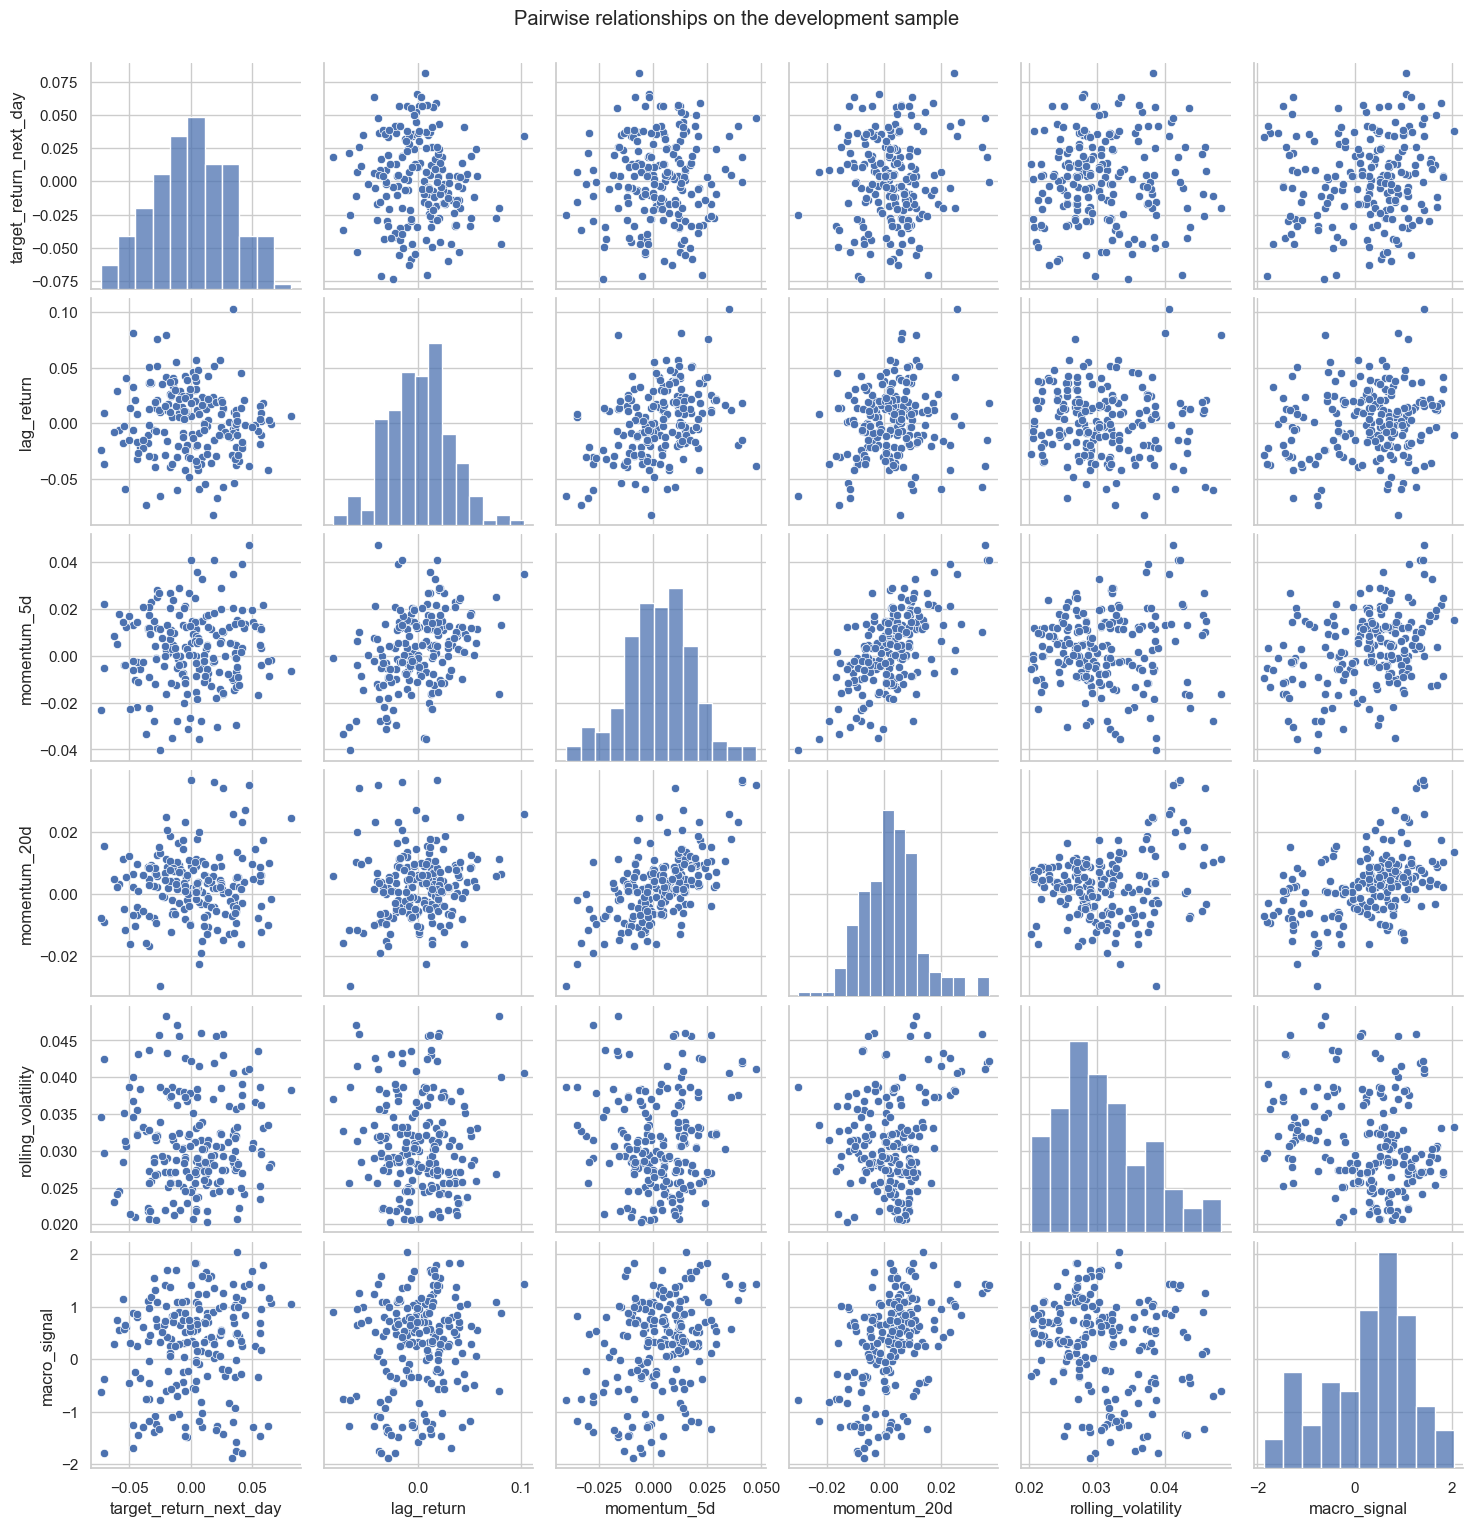

In [17]:
%matplotlib inline

plt.figure(figsize=(12, 4))
plt.plot(dev_df["date"], dev_df["target_return_next_day"], label="target_return_next_day", alpha=0.9)
for col in ["lag_return", "momentum_5d", "momentum_20d", "rolling_volatility", "macro_signal", "vol_regime"]:
    z = (dev_df[col] - dev_df[col].mean()) / (dev_df[col].std() + 1e-12)
    plt.plot(dev_df["date"], z, label=col, alpha=0.6)
plt.title("Development sample: standardized features overlaid with target")
plt.legend(loc="upper right", ncol=3, fontsize=8)
plt.tight_layout()
plt.show()

pair_cols = ["target_return_next_day", "lag_return", "momentum_5d", "momentum_20d", "rolling_volatility", "macro_signal"]
pair_sample = dev_df[pair_cols].dropna().sample(200)
pp = sns.pairplot(pair_sample)
pp.fig.suptitle("Pairwise relationships on the development sample", y=1.02)
plt.show()


We see some linear structure between `target_return`ans soem of the feature, notably `macro_signal`and the momentum features. We can also note the different momentum features are correlated.

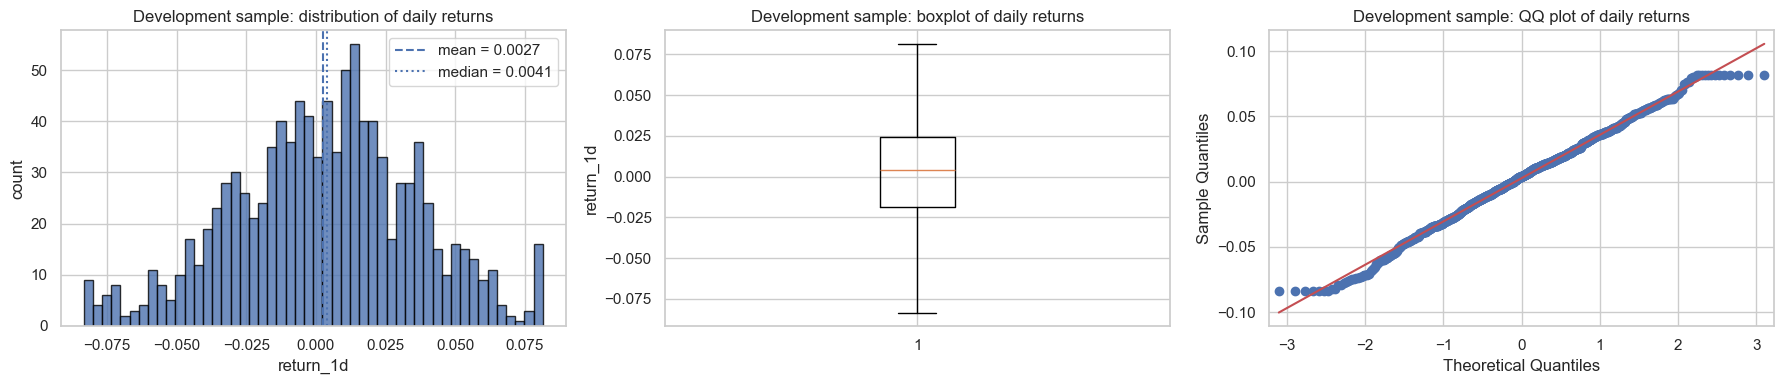

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
stat,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,skewness,excess_kurtosis
value,1043.0,0.002657,0.033183,-0.083428,-0.078407,-0.055034,-0.018859,0.00409,0.024451,0.056665,0.081426,0.081426,-0.121829,-0.114445


In [50]:
# EDA on the distribution of daily returns (development sample)

from scipy.stats import skew, kurtosis

ret = dev_df["return_1d"].dropna()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Histogram
axes[0].hist(ret, bins=50, edgecolor="black", alpha=0.8)
axes[0].axvline(ret.mean(), linestyle="--", label=f"mean = {ret.mean():.4f}")
axes[0].axvline(ret.median(), linestyle=":", label=f"median = {ret.median():.4f}")
axes[0].set_title("Development sample: distribution of daily returns")
axes[0].set_xlabel("return_1d")
axes[0].set_ylabel("count")
axes[0].legend()

# Boxplot
axes[1].boxplot(ret, vert=True)
axes[1].set_title("Development sample: boxplot of daily returns")
axes[1].set_ylabel("return_1d")

# QQ plot
sm.qqplot(ret, line="s", ax=axes[2])
axes[2].set_title("Development sample: QQ plot of daily returns")

plt.tight_layout()
plt.show()

return_dist_summary = pd.DataFrame({
    "stat": [
        "count", "mean", "std", "min", "1%", "5%", "25%", "50%", "75%", "95%", "99%", "max",
        "skewness", "excess_kurtosis"
    ],
    "value": [
        ret.count(),
        ret.mean(),
        ret.std(),
        ret.min(),
        ret.quantile(0.01),
        ret.quantile(0.05),
        ret.quantile(0.25),
        ret.quantile(0.50),
        ret.quantile(0.75),
        ret.quantile(0.95),
        ret.quantile(0.99),
        ret.max(),
        skew(ret, bias=False),
        kurtosis(ret, fisher=True, bias=False),
    ]
})

display(return_dist_summary.T)

--> 
- Daily returns are centered close to zero, with a small positive drift (~0.26%), which remains negligible relative to the overall volatility (~3.3%)
- The distribution is broadly symmetric, with a slightly negative skew (-0.12), suggesting somewhat heavier downside tails
- The QQ plot shows mild deviations from normality in the tails, although the central part of the distribution is reasonably well aligned with a Gaussian
- Extreme values are present but not dominant, which is consistent with the earlier winsorization step

Overall, the distribution is close to Gaussian in the center but exhibits the typical tail behavior observed in financial returns, implying that models relying strictly on normality assumptions should be interpreted with caution

In [59]:
# ADF test on daily returns (development sample)

from statsmodels.tsa.stattools import adfuller

ret = dev_df["return_1d"].dropna()

adf_stat, adf_pvalue, _, _, adf_crit, _ = adfuller(ret, autolag="AIC")

adf_table = pd.DataFrame({
    "test": ["ADF"],
    "null_hypothesis": ["unit root / non-stationary"],
    "test_stat": [adf_stat],
    "p_value": [adf_pvalue],
})

display(adf_table)

print("ADF critical values:", adf_crit)

,test,null_hypothesis,test_stat,p_value
0,ADF,unit root / non-stationary,-11.003556,6.589755e-20


ADF critical values: {'1%': np.float64(-3.4366655541494944), '5%': np.float64(-2.8643284548748533), '10%': np.float64(-2.5682546880209087)}



--> The ADF test strongly rejects the unit root hypothesis (p-value ≪ 1%), suggesting that daily returns can be treated as stationary in mean
--> Applying standard regression models on returns is theoretically justified from a stationarity perspective.

### 4.2 Lag diagnostics

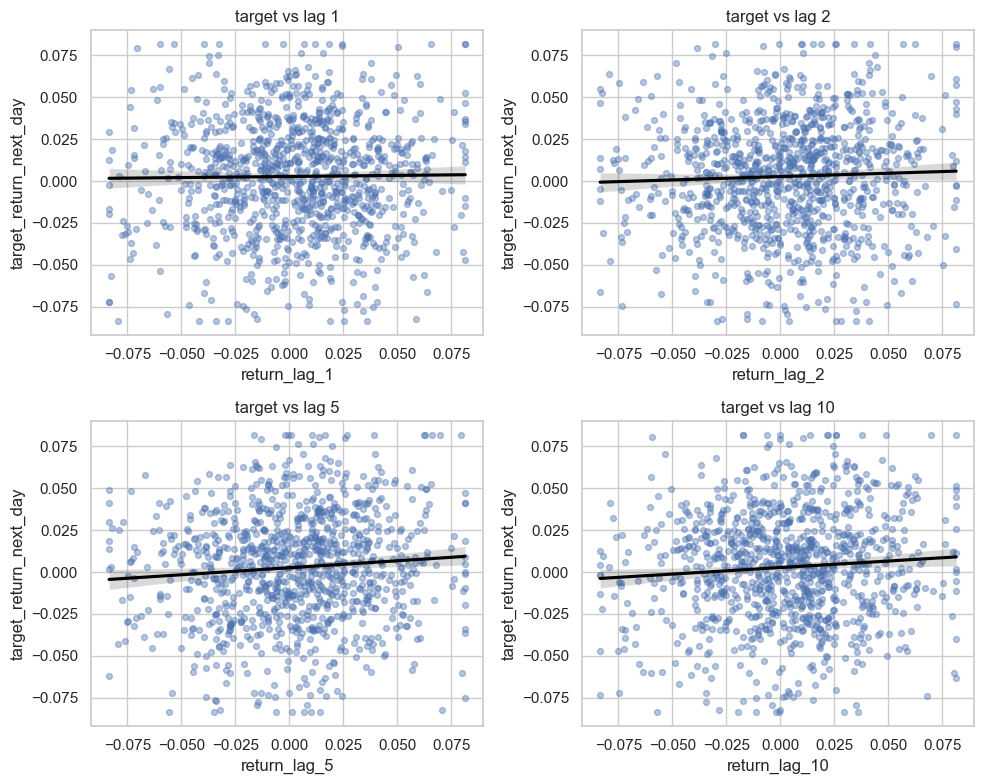

In [20]:
lag_diag = dev_df[["date", "target_return_next_day"]].copy()
for lag in [1, 2, 5, 10]:
    lag_diag[f"return_lag_{lag}"] = dev_df["return_1d"].shift(lag)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, lag in zip(axes.ravel(), [1, 2, 5, 10]):
    sns.regplot(data=lag_diag, x=f"return_lag_{lag}", y="target_return_next_day", ax=ax,
                scatter_kws={"alpha":0.4, "s":18}, line_kws={"color":"black"})
    ax.set_title(f"target vs lag {lag}")
plt.tight_layout()
plt.show()


--> No sign of strong autocorrelation 

### 4.3 Momentum diagnostics

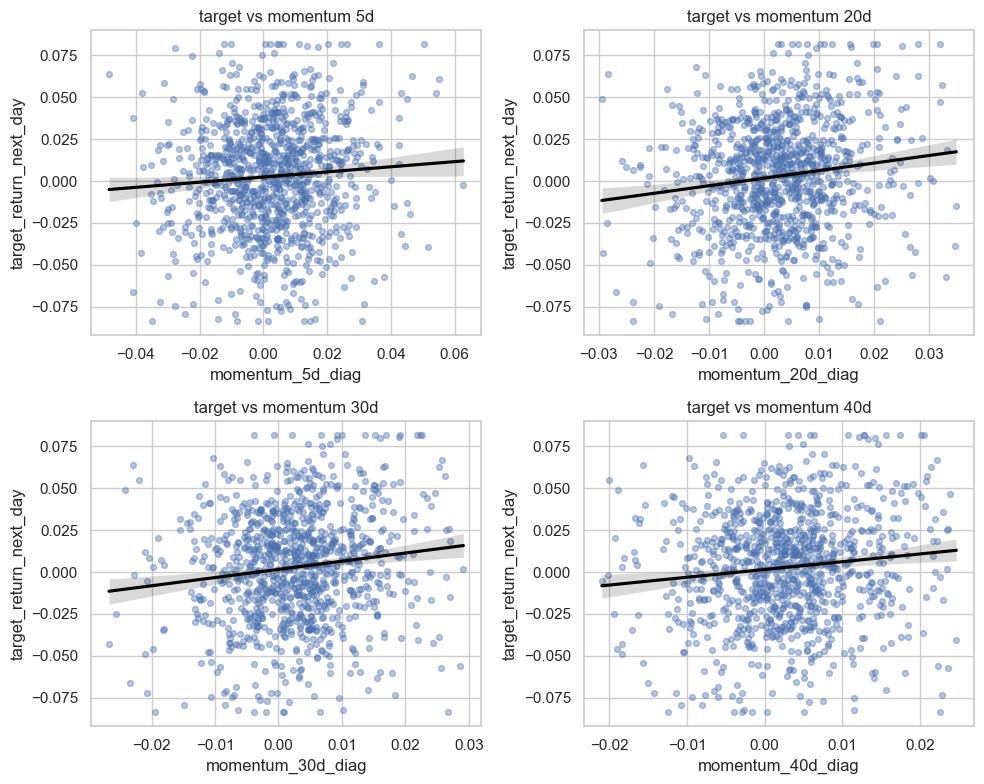

In [21]:

mom_diag = dev_df[["date", "target_return_next_day", "return_1d"]].copy()
for window in [5, 20, 30, 40]:
    mom_diag[f"momentum_{window}d_diag"] = dev_df["return_1d"].rolling(window).mean()

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, window in zip(axes.ravel(), [5, 20, 30, 40]):
    sns.regplot(data=mom_diag, x=f"momentum_{window}d_diag", y="target_return_next_day", ax=ax,
                scatter_kws={"alpha":0.4, "s":18}, line_kws={"color":"black"})
    ax.set_title(f"target vs momentum {window}d")
plt.tight_layout()
plt.show()


--> Weak sign of momentum behavior

### 4.4 Correlation screen for all inspected variables

In [23]:
eda_corr = dev_df[["target_return_next_day", "lag_return", "momentum_5d", "momentum_20d", "rolling_volatility", "macro_signal", "vol_regime"]].copy()
for lag in [1, 2, 5, 10]:
    eda_corr[f"return_lag_{lag}"] = dev_df["return_1d"].shift(lag)
for window in [30, 40]:
    eda_corr[f"momentum_{window}d_diag"] = dev_df["return_1d"].rolling(window).mean()

corr_table = eda_corr.corr(numeric_only=True)[["target_return_next_day"]].drop(index=["target_return_next_day"])
corr_table = corr_table.rename(columns={"target_return_next_day": "corr_with_target"}).sort_values("corr_with_target", ascending=False)
display(corr_table)


,corr_with_target
macro_signal,0.165583
momentum_20d,0.136150
momentum_30d_diag,0.129993
momentum_40d_diag,0.112945
momentum_5d,0.097610
return_lag_5,0.083220
return_lag_10,0.077638
vol_regime,0.053410
rolling_volatility,0.051287
return_lag_2,0.040005


--> Relatively high correlation with macro_signal and momentum_20d, suggesting they will be good candidates to extract predictive power

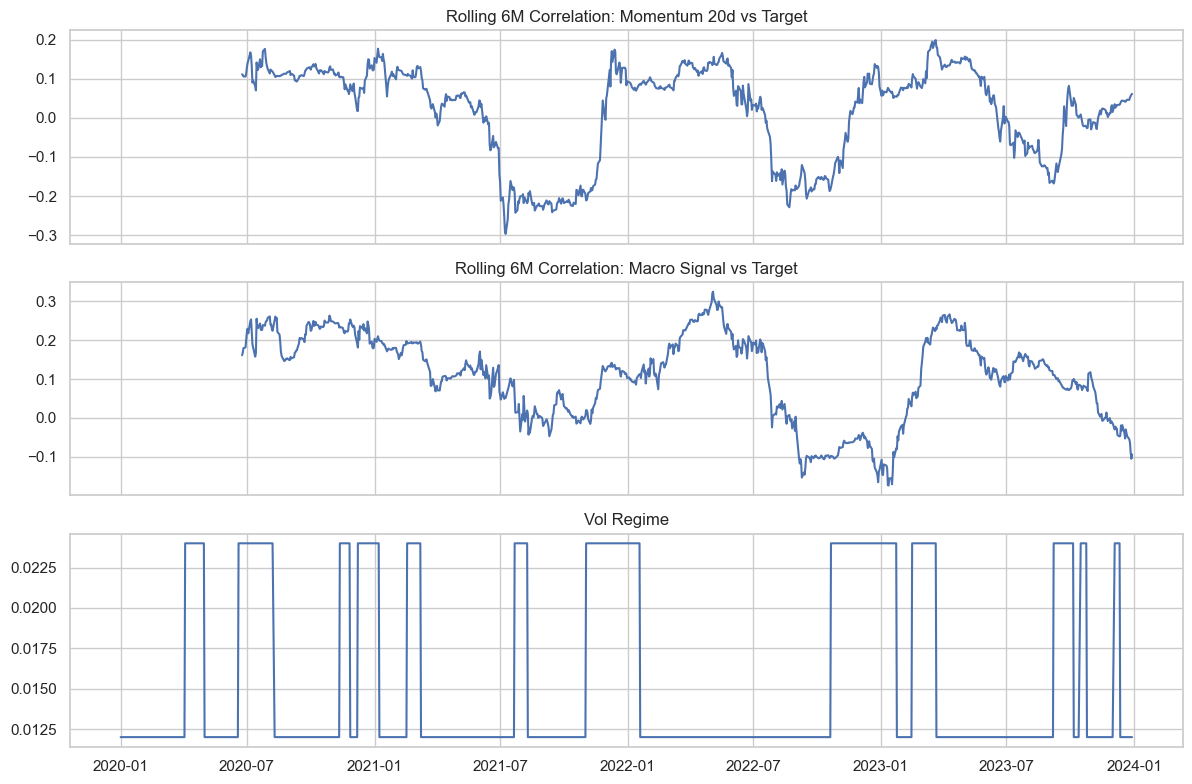

In [24]:
# Inspecting robustness of macro-target and momentum-target correlation through time

window = 126  # ~6 months of trading days

tmp = dev_df.copy()

# Rolling correlations
tmp["corr_mom20_target"] = tmp["momentum_20d"].rolling(window).corr(tmp["target_return_next_day"])
tmp["corr_macro_target"] = tmp["macro_signal"].fillna(0).rolling(window).corr(tmp["target_return_next_day"])

# Plot
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# (1) Momentum 20d vs target
axes[0].plot(tmp["date"], tmp["corr_mom20_target"])
axes[0].set_title("Rolling 6M Correlation: Momentum 20d vs Target")

# (2) Macro signal vs target
axes[1].plot(tmp["date"], tmp["corr_macro_target"])
axes[1].set_title("Rolling 6M Correlation: Macro Signal vs Target")

# (3) Vol regime
axes[2].plot(tmp["date"], tmp["vol_regime"])
axes[2].set_title("Vol Regime")

plt.tight_layout()
plt.show()

In [25]:
tmp = dev_df.copy()
tmp["target"] = tmp["target_return_next_day"]

res = tmp.groupby("vol_regime").apply(
    lambda g: pd.Series({
        "corr_mom20": g["momentum_20d"].corr(g["target"]),
        "corr_macro": g["macro_signal"].corr(g["target"]),
        "n": len(g)
    })
)
print(res)

            corr_mom20  corr_macro      n
vol_regime                               
0.012         0.024789    0.104955  744.0
0.024         0.236916    0.278454  299.0



--> The signal concentrates in high-volatility regimes. A plausible interpretation is that macro information propagates more slowly and nonlinearly during stress, creating temporary inefficiencies. Outside those regimes, the signal largely disappears

--> This is pushing for the creation of regime dependent features

Note: Given the relatively small dataset (~1300 observations), reducing feature redundancy will help limit overfitting and improves generalization. Thus, I will not add any additional lag features given the absence of autocorrelation evidence, and I will keep only the 20_day momentum feature as all momentum features are highly correlated and the 20d one seems to be the one best capturing the trend. 

## 5. Feature creation for modeling

In [26]:
feat_df = df.copy()

# Clean macro (causal)
macro_expanding_mean = feat_df["macro_signal"].expanding().mean().shift(1)
feat_df["macro_signal"] = feat_df["macro_signal"].fillna(macro_expanding_mean)
feat_df["macro_signal"] = feat_df["macro_signal"].fillna(feat_df["macro_signal"].median()) # added to handle if we have NAs at the beggining of the series 

# Vol normalization
den = feat_df["rolling_volatility"].replace(0, np.nan)
feat_df["mom20_over_vol"] = feat_df["momentum_20d"] / den
feat_df["lag_over_vol"] = feat_df["lag_return"] / den

# Regime indicator (no leakage: fixed threshold) ---
feat_df["is_high_vol"] = (feat_df["vol_regime"] > 0.018).astype(int)

# Regime-dependent features (no leakage: fixed threshold for the regime indicator) 
feat_df["is_high_vol"] = (feat_df["vol_regime"] > 0.018).astype(int)
feat_df["macro_high_vol"] = feat_df["macro_signal"] * feat_df["is_high_vol"]
feat_df["mom20_high_vol"] = feat_df["momentum_20d"] * feat_df["is_high_vol"]

# --- Final cleanup ---
feat_df = feat_df.dropna().reset_index(drop=True)

# --- Feature list ---
feature_cols = [
    "lag_return",
    "momentum_20d",
    "rolling_volatility",
    "macro_signal",
    "mom20_over_vol",
    "lag_over_vol",
    "macro_high_vol",
    "mom20_high_vol"
]

print("Feature matrix shape:", feat_df[feature_cols].shape)
display(pd.DataFrame({"feature": feature_cols}))

Feature matrix shape: (1303, 8)


,feature
0,lag_return
1,momentum_20d
2,rolling_volatility
3,macro_signal
4,mom20_over_vol
5,lag_over_vol
6,macro_high_vol
7,mom20_high_vol


Important caveat on the existing features: Due to time constraints, I do not inspect in detail how the pre-existing features were originally constructed. In a production-grade research process, this step would be necessary before drawing definitive conclusions.

In particular, I would want to verify that:
- all rolling features are computed using only information available at time
- any normalization, imputation, or transformation is applied in a causal way
- no feature contains forward-looking information because of alignment or preprocessing choices

## 6. Development split for model selection

In [27]:
holdout_size_feat = int(len(feat_df) * holdout_frac)

dev_feat = feat_df.iloc[:-holdout_size_feat].copy()
holdout_feat = feat_df.iloc[-holdout_size_feat:].copy()

dev_test_frac = 0.20
dev_test_size = int(len(dev_feat) * dev_test_frac)
train_df = dev_feat.iloc[:-dev_test_size].copy()
dev_test_df = dev_feat.iloc[-dev_test_size:].copy()

display(pd.DataFrame({
    "sample": ["train", "dev_test", "holdout"],
    "rows": [len(train_df), len(dev_test_df), len(holdout_feat)],
    "start_date": [train_df["date"].min(), dev_test_df["date"].min(), holdout_feat["date"].min()],
    "end_date": [train_df["date"].max(), dev_test_df["date"].max(), holdout_feat["date"].max()],
}))

X_train = train_df[feature_cols]
y_train = train_df["target_return_next_day"]
X_dev_test = dev_test_df[feature_cols]
y_dev_test = dev_test_df["target_return_next_day"]
X_holdout = holdout_feat[feature_cols]
y_holdout = holdout_feat["target_return_next_day"]

,sample,rows,start_date,end_date
0,train,835,2020-01-01,2023-03-14
1,dev_test,208,2023-03-15,2023-12-29
2,holdout,260,2024-01-01,2024-12-27


## 7. Models

In [28]:
# Ridge model 

ridge_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge())
])
ridge_grid = {"model__alpha": np.logspace(-2, 2, 8)}
tscv = TimeSeriesSplit(n_splits=5)

grid_ridge = GridSearchCV(
    ridge_pipe,
    ridge_grid,
    cv=tscv,
    scoring="neg_mean_squared_error",
    n_jobs=1
)
grid_ridge.fit(X_train, y_train)
ridge_best = grid_ridge.best_estimator_
ridge_pred_dev = ridge_best.predict(X_dev_test)

In [29]:
# RF model 

rf_pipe = Pipeline([
    ("model", RandomForestRegressor(random_state=42))
])
rf_grid = {
    "model__n_estimators": [50, 150, 300, 500],
    "model__max_depth": [2, 4, 6],
    "model__min_samples_leaf": [5, 10, 20],
}
grid_rf = GridSearchCV(
    rf_pipe,
    rf_grid,
    cv=tscv,
    scoring="neg_mean_squared_error",
    n_jobs=1
)
grid_rf.fit(X_train, y_train)
rf_best = grid_rf.best_estimator_
rf_pred_dev = rf_best.predict(X_dev_test)

In [30]:
# Naive constant baseline: predict the train mean

naive_mean_pred_dev = np.full(len(y_dev_test), y_train.mean())

In [32]:
# Displaying results 

def regression_summary(y_true, y_pred, label):
    y_true_arr = np.asarray(y_true)
    y_pred_arr = np.asarray(y_pred)

    if np.std(y_pred_arr) < 1e-12:
        corr = np.nan
    else:
        corr = float(np.corrcoef(y_true_arr, y_pred_arr)[0, 1])

    return {
        "model": label,
        "rmse": float(np.sqrt(mean_squared_error(y_true_arr, y_pred_arr))),
        "r2": float(r2_score(y_true_arr, y_pred_arr)),
        "corr": corr,
    }

model_results = pd.DataFrame([
    regression_summary(y_dev_test, naive_mean_pred_dev, "Naive mean"),
    regression_summary(y_dev_test, ridge_pred_dev, "Ridge"),
    regression_summary(y_dev_test, rf_pred_dev, "RandomForest"),
]).sort_values("rmse")

display(model_results)
print("Best Ridge alpha:", grid_ridge.best_params_)
print("Best RF params:", grid_rf.best_params_)
print("Naive mean used:", float(y_train.mean()))

,model,rmse,r2,corr
1,Ridge,0.032871,0.012151,0.111014
2,RandomForest,0.032967,0.006324,0.147479
0,Naive mean,0.034247,-0.072322,NaN


Best Ridge alpha: {'model__alpha': np.float64(100.0)}
Best RF params: {'model__max_depth': 2, 'model__min_samples_leaf': 10, 'model__n_estimators': 300}
Naive mean used: 0.004450512125690788


--> Ridge and RF marginally better than naive model in terms of RMSE, strong regularization in Ridge suggests low to modest predictive power of the signals 

In [60]:
# Walk-forward validation on the development sample
# Uses the same engineered features and the selected Ridge alpha

wf_df = dev_feat.copy().dropna(subset=feature_cols + ["target_return_next_day"]).reset_index(drop=True)

X_wf = wf_df[feature_cols]
y_wf = wf_df["target_return_next_day"]
dates_wf = wf_df["date"]

tscv_wf = TimeSeriesSplit(n_splits=5)

wf_rows = []
wf_pred_blocks = []

for fold, (train_idx, test_idx) in enumerate(tscv_wf.split(X_wf), start=1):
    X_train_fold = X_wf.iloc[train_idx]
    y_train_fold = y_wf.iloc[train_idx]
    X_test_fold = X_wf.iloc[test_idx]
    y_test_fold = y_wf.iloc[test_idx]
    d_test_fold = dates_wf.iloc[test_idx]

    ridge_fold = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=grid_ridge.best_params_["model__alpha"]))
    ])

    ridge_fold.fit(X_train_fold, y_train_fold)
    y_pred_fold = ridge_fold.predict(X_test_fold)

    fold_corr = np.corrcoef(y_test_fold, y_pred_fold)[0, 1] if np.std(y_pred_fold) > 1e-12 else np.nan

    wf_rows.append({
        "fold": fold,
        "train_start": dates_wf.iloc[train_idx].min(),
        "train_end": dates_wf.iloc[train_idx].max(),
        "test_start": d_test_fold.min(),
        "test_end": d_test_fold.max(),
        "n_train": len(train_idx),
        "n_test": len(test_idx),
        "rmse": np.sqrt(mean_squared_error(y_test_fold, y_pred_fold)),
        "r2": r2_score(y_test_fold, y_pred_fold),
        "corr": fold_corr,
    })

    wf_pred_blocks.append(pd.DataFrame({
        "date": d_test_fold.values,
        "y_true": y_test_fold.values,
        "y_pred": y_pred_fold,
        "fold": fold,
    }))

wf_results = pd.DataFrame(wf_rows)
wf_preds = pd.concat(wf_pred_blocks, ignore_index=True)

display(wf_results)

wf_summary = pd.DataFrame({
    "metric": ["mean_rmse", "mean_r2", "mean_corr", "std_corr"],
    "value": [
        wf_results["rmse"].mean(),
        wf_results["r2"].mean(),
        wf_results["corr"].mean(),
        wf_results["corr"].std(),
    ]
})

display(wf_summary)

,fold,train_start,train_end,test_start,test_end,n_train,n_test,rmse,r2,corr
0,1,2020-01-01,2020-09-04,2020-09-07,2021-05-05,178,173,0.030561,-0.011096,0.120272
1,2,2020-01-01,2021-05-05,2021-05-06,2022-01-03,351,173,0.033527,0.030006,0.191565
2,3,2020-01-01,2022-01-03,2022-01-04,2022-09-01,524,173,0.029047,0.015339,0.130483
3,4,2020-01-01,2022-09-01,2022-09-02,2023-05-02,697,173,0.034665,0.030484,0.200218
4,5,2020-01-01,2023-05-02,2023-05-03,2023-12-29,870,173,0.033688,0.012141,0.115115


,metric,value
0,mean_rmse,0.032298
1,mean_r2,0.015375
2,mean_corr,0.151531
3,std_corr,0.040986


--> 
- The model exhibits a consistently positive predictive correlation across all folds (~0.15 on average), suggesting the presence of a stable signal
- The relatively low dispersion of correlation across folds indicates reasonable temporal robustness
- The magnitude of the correlation is relatively strong for a pure time-series setting, which may reflect the informative nature of the pre-engineered features; in a production setting, this would warrant a careful audit of feature construction to rule out any potential leakage or overly optimistic structure

## 8. Inspect the Ridge and RF models

In [33]:
# Ridge coeff

ridge_coef = pd.DataFrame({
    "feature": feature_cols,
    "coef": ridge_best.named_steps["model"].coef_
}).sort_values("coef", ascending=False)
display(ridge_coef)

,feature,coef
6,macro_high_vol,0.002960
3,macro_signal,0.002574
7,mom20_high_vol,0.001791
1,momentum_20d,0.000986
0,lag_return,0.000742
2,rolling_volatility,0.000265
4,mom20_over_vol,-0.000215
5,lag_over_vol,-0.002203


In [35]:
# RF importance

rf_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_best.named_steps["model"].feature_importances_
}).sort_values("importance", ascending=False)

display(rf_importance)

,feature,importance
6,macro_high_vol,0.469483
3,macro_signal,0.162225
7,mom20_high_vol,0.140071
0,lag_return,0.053084
2,rolling_volatility,0.050366
5,lag_over_vol,0.044343
1,momentum_20d,0.041725
4,mom20_over_vol,0.038704


--> Both models are consistent in terms of feature predictive power, showing `macro_high_vol`, `macro_signal` and `mom20_high_vol`as the most important features. 
That suggests relationships are mainly linears, if features had strong non linear predictive power they would be higher in RF feature importance ranking

## 9. Ridge and RF diagnostics on the development test

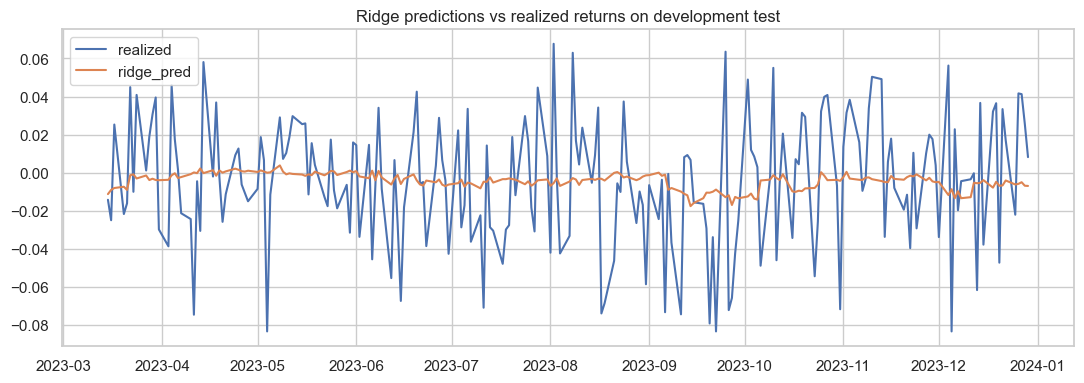

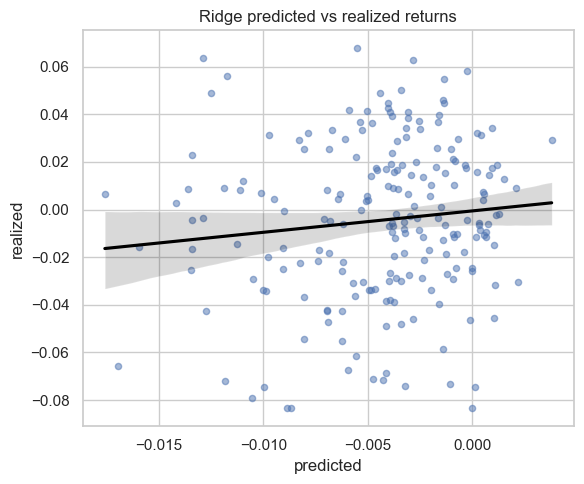

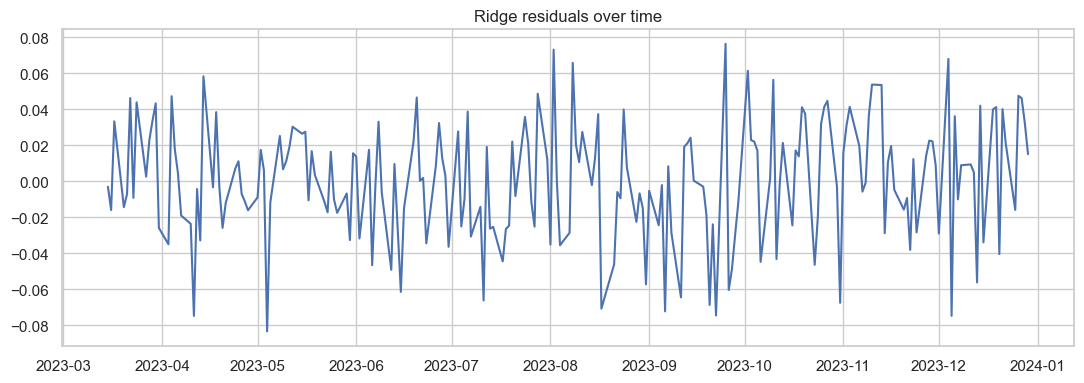

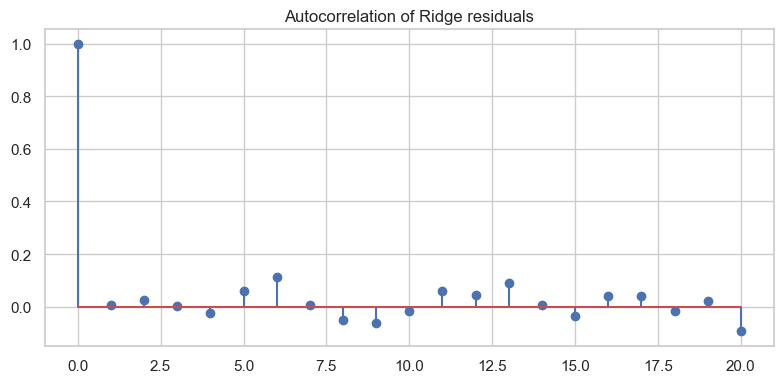

,lb_stat,lb_pvalue
5,1.021068,0.960849
10,5.292849,0.870777


In [39]:
# Ridge 

ridge_diag = pd.DataFrame({
    "date": dev_test_df["date"].values,
    "realized": y_dev_test.values,
    "predicted": ridge_pred_dev,
})
ridge_diag["residual"] = ridge_diag["realized"] - ridge_diag["predicted"]

plt.figure(figsize=(11, 4))
plt.plot(ridge_diag["date"], ridge_diag["realized"], label="realized")
plt.plot(ridge_diag["date"], ridge_diag["predicted"], label="ridge_pred")
plt.title("Ridge predictions vs realized returns on development test")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
sns.regplot(data=ridge_diag, x="predicted", y="realized", scatter_kws={"alpha":0.5, "s":20}, line_kws={"color":"black"})
plt.title("Ridge predicted vs realized returns")
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 4))
plt.plot(ridge_diag["date"], ridge_diag["residual"])
plt.title("Ridge residuals over time")
plt.tight_layout()
plt.show()

acf_vals = acf(ridge_diag["residual"], nlags=20, fft=False)
plt.figure(figsize=(8, 4))
plt.stem(range(len(acf_vals)), acf_vals)
plt.title("Autocorrelation of Ridge residuals")
plt.tight_layout()
plt.show()

display(acorr_ljungbox(ridge_diag["residual"], lags=[5, 10], return_df=True))


Few observations:
- Predicted returns are highly smoothed and remain close to zero compared to the much more volatile realized returns, consistently with the strong regularization factor
- The scatter plot shows a weak positive relationship between predictions and realized values, suggesting minimal predictive power
- Residuals are centered around zero with no visible trend over time, indicating no systematic bias in the model
- The autocorrelation function (ACF) of residuals shows no significant lags beyond zero, suggesting absence remaining of linear temporal dependence
- Ljung-Box test p-values are high, confirming that residuals are consistent with white noise (no autocorrelation)

--> Overall, the model is statistically well-behaved (uncorrelated residuals) but captures very little signal, making its predictive performance weak.

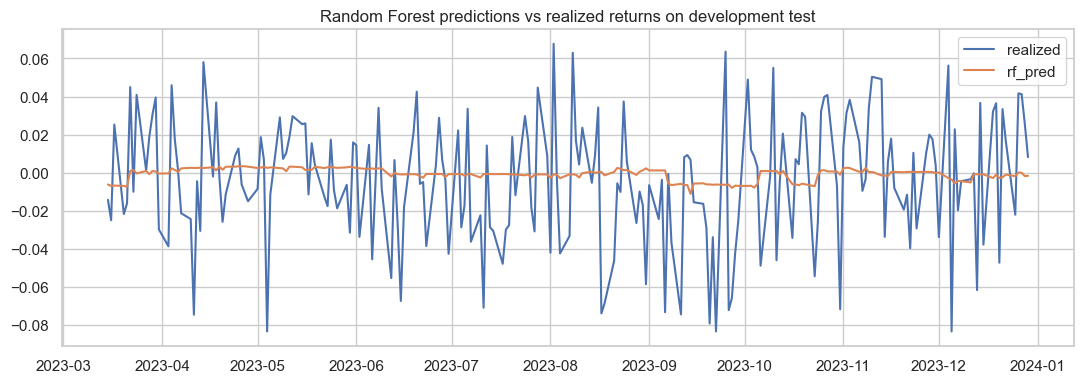

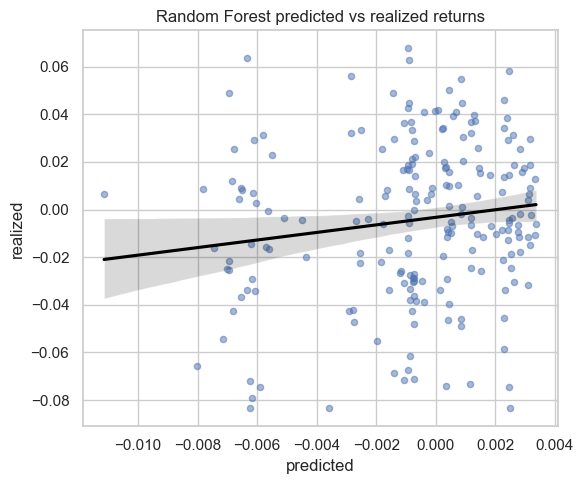

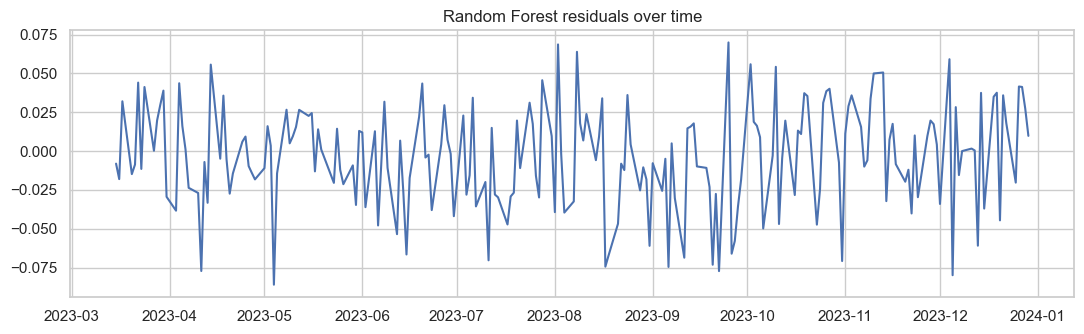

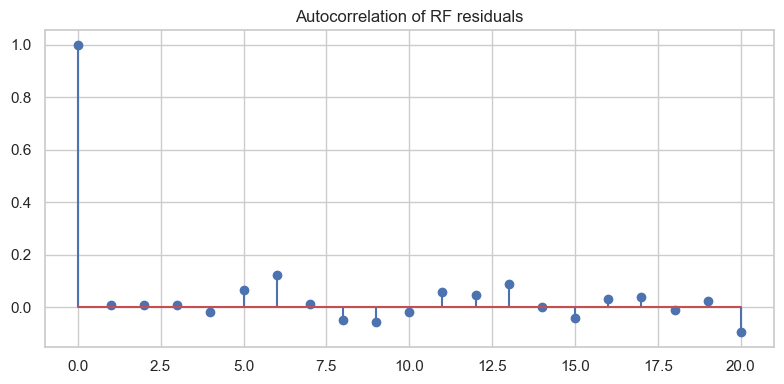

,lb_stat,lb_pvalue
5,1.051261,0.958326
10,5.582547,0.849033


In [40]:
rf_diag = pd.DataFrame({
    "date": dev_test_df["date"].values,
    "realized": y_dev_test.values,
    "predicted": rf_pred_dev,
})
rf_diag["residual"] = rf_diag["realized"] - rf_diag["predicted"]

# --- Time series plot ---
plt.figure(figsize=(11, 4))
plt.plot(rf_diag["date"], rf_diag["realized"], label="realized")
plt.plot(rf_diag["date"], rf_diag["predicted"], label="rf_pred")
plt.title("Random Forest predictions vs realized returns on development test")
plt.legend()
plt.tight_layout()
plt.show()

# --- Scatter plot ---
plt.figure(figsize=(6, 5))
sns.regplot(
    data=rf_diag,
    x="predicted",
    y="realized",
    scatter_kws={"alpha": 0.5, "s": 20},
    line_kws={"color": "black"}
)
plt.title("Random Forest predicted vs realized returns")
plt.tight_layout()
plt.show()

# --- Residuals over time ---
plt.figure(figsize=(11, 3.5))
plt.plot(rf_diag["date"], rf_diag["residual"])
plt.title("Random Forest residuals over time")
plt.tight_layout()
plt.show()

# --- ACF of residuals ---
acf_vals = acf(rf_diag["residual"], nlags=20, fft=False)
plt.figure(figsize=(8, 4))
plt.stem(range(len(acf_vals)), acf_vals)
plt.title("Autocorrelation of RF residuals")
plt.tight_layout()
plt.show()

# --- Ljung-Box test ---
display(acorr_ljungbox(rf_diag["residual"], lags=[5, 10], return_df=True))

Same overall conclusion as Ridge: Random Forest captures only marginally more signal (slightly higher dispersion and correlation), but predictive power remains weak and dominated by noise

## 10. Translate predictions into trading strategies

In [69]:
def backtest_from_prediction(y_true, y_pred, dates, cost_per_turnover=0.0005, clip_at=1.0):
    y_true = pd.Series(np.asarray(y_true), index=pd.Index(dates), name="asset_return")
    y_pred = pd.Series(np.asarray(y_pred), index=pd.Index(dates), name="prediction")

    scale = y_pred.std() + 1e-12
    position = (y_pred / scale).clip(-clip_at, clip_at)

    turnover = position.diff().abs().fillna(position.abs())
    gross = position * y_true
    net = gross - cost_per_turnover * turnover

    out = pd.DataFrame({
        "date": y_true.index,
        "asset_return": y_true.values,
        "prediction": y_pred.values,
        "position": position.values,
        "turnover": turnover.values,
        "strategy_return": net.values,
    }).set_index("date")

    out["cum_return"] = (1 + out["strategy_return"]).cumprod()
    return out


def backtest_hold(y_true, dates, cost_per_turnover=0.0005):
    y_true = pd.Series(np.asarray(y_true), index=pd.Index(dates), name="asset_return")
    position = pd.Series(1.0, index=y_true.index, name="position")

    turnover = position.diff().abs().fillna(position.abs())
    gross = position * y_true
    net = gross - cost_per_turnover * turnover

    out = pd.DataFrame({
        "date": y_true.index,
        "asset_return": y_true.values,
        "prediction": np.nan,
        "position": position.values,
        "turnover": turnover.values,
        "strategy_return": net.values,
    }).set_index("date")

    out["cum_return"] = (1 + out["strategy_return"]).cumprod()
    return out


# Refit final models on all development data
X_dev_all = dev_feat[feature_cols]
y_dev_all = dev_feat["target_return_next_day"]

final_ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=grid_ridge.best_params_["model__alpha"]))
])
final_ridge.fit(X_dev_all, y_dev_all)

final_rf = RandomForestRegressor(
    random_state=42,
    n_estimators=grid_rf.best_params_["model__n_estimators"],
    max_depth=grid_rf.best_params_["model__max_depth"],
    min_samples_leaf=grid_rf.best_params_["model__min_samples_leaf"],
)
final_rf.fit(X_dev_all, y_dev_all)

# Predictions on full sample
feat_df = feat_df.copy()
feat_df["ridge_pred_fullsample_refit"] = final_ridge.predict(feat_df[feature_cols])
feat_df["rf_pred_fullsample_refit"] = final_rf.predict(feat_df[feature_cols])

# Predictions on holdout
holdout_ridge_pred = final_ridge.predict(X_holdout)
holdout_rf_pred = final_rf.predict(X_holdout)

# Full sample backtests - strength only
full_ridge_strength_bt = backtest_from_prediction(
    feat_df["target_return_next_day"],
    feat_df["ridge_pred_fullsample_refit"],
    feat_df["date"]
)

full_rf_strength_bt = backtest_from_prediction(
    feat_df["target_return_next_day"],
    feat_df["rf_pred_fullsample_refit"],
    feat_df["date"]
)

full_hold_bt = backtest_hold(
    feat_df["target_return_next_day"],
    feat_df["date"]
)

# Holdout backtests - strength only
holdout_ridge_strength_bt = backtest_from_prediction(
    y_holdout,
    holdout_ridge_pred,
    holdout_feat["date"]
)

holdout_rf_strength_bt = backtest_from_prediction(
    y_holdout,
    holdout_rf_pred,
    holdout_feat["date"]
)

holdout_hold_bt = backtest_hold(
    y_holdout,
    holdout_feat["date"]
)

In [70]:
def strategy_summary(bt_df, label):
    r = bt_df["strategy_return"]
    mean_daily = r.mean()
    std_daily = r.std()
    sharpe = np.sqrt(252) * mean_daily / (std_daily + 1e-12)
    ann_return = (1 + mean_daily) ** 252 - 1
    max_dd = (bt_df["cum_return"] / bt_df["cum_return"].cummax() - 1).min()

    return {
        "strategy": label,
        "mean_daily_return": float(mean_daily),
        "annualized_return": float(ann_return),
        "annualized_vol": float(std_daily * np.sqrt(252)),
        "sharpe": float(sharpe),
        "max_drawdown": float(max_dd),
        "avg_turnover": float(bt_df["turnover"].mean()),
        "annualized_turnover": float(bt_df["turnover"].mean() * 252),
    }

full_perf = pd.DataFrame([
    strategy_summary(full_ridge_strength_bt, "Ridge strength"),
    strategy_summary(full_rf_strength_bt, "RF strength"),
    strategy_summary(full_hold_bt, "Hold"),
]).sort_values("sharpe", ascending=False)

holdout_perf = pd.DataFrame([
    strategy_summary(holdout_ridge_strength_bt, "Ridge strength"),
    strategy_summary(holdout_rf_strength_bt, "RF strength"),
    strategy_summary(holdout_hold_bt, "Hold"),
]).sort_values("sharpe", ascending=False)

print("Full-sample trading performance")
display(full_perf)

print("Final holdout trading performance")
display(holdout_perf)

Full-sample trading performance


,strategy,mean_daily_return,annualized_return,annualized_vol,sharpe,max_drawdown,avg_turnover,annualized_turnover
1,RF strength,0.004144,1.835284,0.334009,3.126564,-0.200697,0.092876,23.404676
0,Ridge strength,0.004168,1.852491,0.379374,2.768708,-0.260595,0.152143,38.339970
2,Hold,0.000864,0.243033,0.536068,0.406008,-0.968938,0.000767,0.193400


Final holdout trading performance


,strategy,mean_daily_return,annualized_return,annualized_vol,sharpe,max_drawdown,avg_turnover,annualized_turnover
0,Ridge strength,0.003851,1.633923,0.511263,1.897924,-0.271320,0.115811,29.184312
1,RF strength,0.002322,0.793832,0.402471,1.453601,-0.243123,0.130737,32.945713
2,Hold,-0.006410,-0.802196,0.558289,-2.893264,-0.862522,0.003846,0.969231


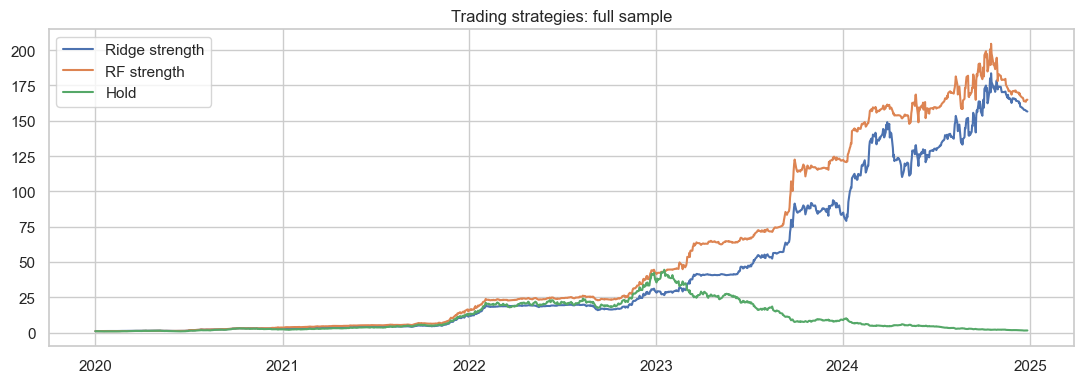

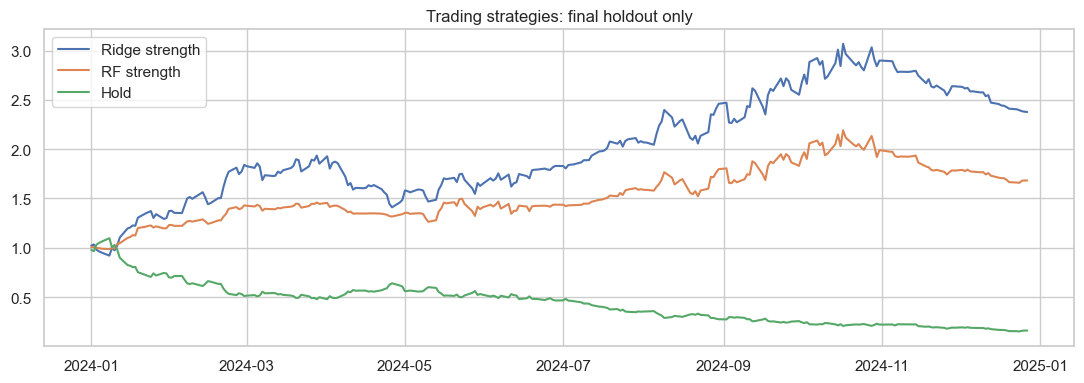

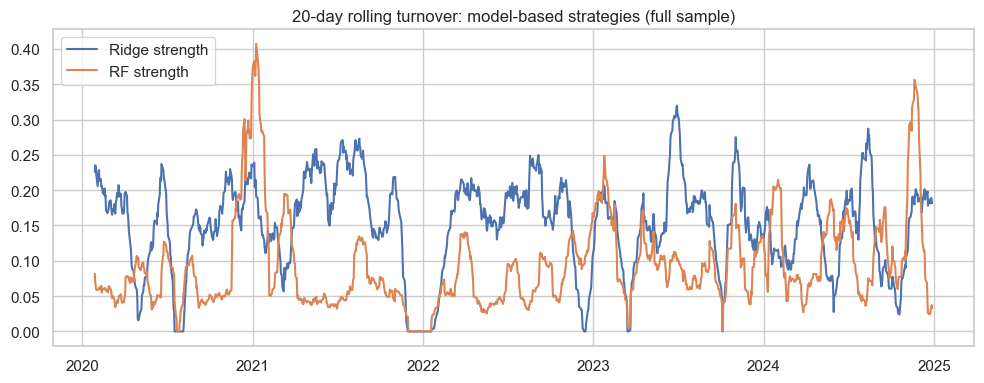

In [71]:
# --- Full sample cumulative returns ---
plt.figure(figsize=(11, 4))
plt.plot(full_ridge_strength_bt.index, full_ridge_strength_bt["cum_return"], label="Ridge strength")
plt.plot(full_rf_strength_bt.index, full_rf_strength_bt["cum_return"], label="RF strength")
plt.plot(full_hold_bt.index, full_hold_bt["cum_return"], label="Hold")
plt.title("Trading strategies: full sample")
plt.legend()
plt.tight_layout()
plt.show()

# --- Holdout cumulative returns ---
plt.figure(figsize=(11, 4))
plt.plot(holdout_ridge_strength_bt.index, holdout_ridge_strength_bt["cum_return"], label="Ridge strength")
plt.plot(holdout_rf_strength_bt.index, holdout_rf_strength_bt["cum_return"], label="RF strength")
plt.plot(holdout_hold_bt.index, holdout_hold_bt["cum_return"], label="Hold")
plt.title("Trading strategies: final holdout only")
plt.legend()
plt.tight_layout()
plt.show()

# --- Turnover (full sample) ---
plt.figure(figsize=(10, 4))
plt.plot(full_ridge_strength_bt.index, full_ridge_strength_bt["turnover"].rolling(20).mean(), label="Ridge strength")
plt.plot(full_rf_strength_bt.index, full_rf_strength_bt["turnover"].rolling(20).mean(), label="RF strength")
plt.title("20-day rolling turnover: model-based strategies (full sample)")
plt.legend()
plt.tight_layout()
plt.show()

--> 
- RF outperforms Ridge in-sample but shows larger Sharpe decay out-of-sample, indicating potential overfitting
- Ridge delivers more stable performance and retains a higher fraction of its Sharpe on the holdout
- This pattern is consistent with RF capturing noise, while Ridge focuses on more robust signal
- In a production context, Ridge would be preferred due to better generalization

In [73]:
# --- Sensitivity of holdout Ridge-strength Sharpe to transaction costs ---

cost_bps_grid = [0, 5, 10, 15, 20, 25, 30]

ridge_cost_sensitivity_rows = []

for cost_bps in cost_bps_grid:
    cost_decimal = cost_bps / 10000.0  # 1 bp = 0.0001
    
    bt = backtest_from_prediction(
        y_holdout,
        holdout_ridge_pred,
        holdout_feat["date"],
        cost_per_turnover=cost_decimal
    )
    
    perf = strategy_summary(bt, f"Ridge strength ({cost_bps} bps)")
    
    ridge_cost_sensitivity_rows.append({
        "transaction_cost_bps": cost_bps,
        "mean_daily_return": perf["mean_daily_return"],
        "annualized_return": perf["annualized_return"],
        "annualized_vol": perf["annualized_vol"],
        "sharpe": perf["sharpe"],
        "max_drawdown": perf["max_drawdown"],
        "avg_turnover": perf["avg_turnover"],
        "annualized_turnover": perf["annualized_turnover"],
    })

ridge_cost_sensitivity = pd.DataFrame(ridge_cost_sensitivity_rows)

print("Holdout sensitivity of Ridge-strength strategy to transaction costs")
display(ridge_cost_sensitivity)

Holdout sensitivity of Ridge-strength strategy to transaction costs


,transaction_cost_bps,mean_daily_return,annualized_return,annualized_vol,sharpe,max_drawdown,avg_turnover,annualized_turnover
0,0,0.003908,1.672488,0.511157,1.926864,-0.27132,0.115811,29.184312
1,5,0.003851,1.633923,0.511263,1.897924,-0.27132,0.115811,29.184312
2,10,0.003793,1.595911,0.511373,1.868978,-0.27132,0.115811,29.184312
3,15,0.003735,1.558446,0.511489,1.840028,-0.27132,0.115811,29.184312
4,20,0.003677,1.521520,0.511609,1.811073,-0.27132,0.115811,29.184312
5,25,0.003619,1.485125,0.511734,1.782116,-0.27132,0.115811,29.184312
6,30,0.003561,1.449252,0.511863,1.753157,-0.27132,0.115811,29.184312


--> 
- Relatively mild Sharpe decay as transaction costs increase, this is a reassuring sign of robustness given the observed turnover (~30 annualized)
- Additional effects such as slippage market impact are not captured here and could further affect realized performance

## 11. Statistical inference on strategy returns

In [74]:
def iid_ttest_summary(strategy_returns):
    r = pd.Series(strategy_returns).dropna()
    t_stat, p_value = stats.ttest_1samp(r, 0.0)
    return {
        "n_obs": int(len(r)),
        "mean_return": float(r.mean()),
        "t_stat_iid": float(t_stat),
        "p_value_iid": float(p_value),
    }


def newey_west_mean_test(strategy_returns, maxlags=5):
    r = pd.Series(strategy_returns).dropna()
    X = np.ones((len(r), 1))
    fit = sm.OLS(r.values, X).fit(cov_type="HAC", cov_kwds={"maxlags": maxlags})
    return {
        "mean_return": float(fit.params[0]),
        "se_newey_west": float(fit.bse[0]),
        "t_stat_newey_west": float(fit.tvalues[0]),
        "p_value_newey_west": float(fit.pvalues[0]),
        "maxlags": int(maxlags),
    }

In [76]:
# Holdout inference: use one consistent naming convention everywhere
holdout_inference = {
    "Ridge strength": holdout_ridge_strength_bt["strategy_return"],
    "Hold": holdout_hold_bt["strategy_return"],
}

iid_rows = []
nw_rows = []
raw_pvals = []

for label, r in holdout_inference.items():
    iid_stats = iid_ttest_summary(r)
    iid_rows.append({
        "strategy": label,
        "n_obs": iid_stats["n_obs"],
        "mean_return": iid_stats["mean_return"],
        "t_stat_iid": iid_stats["t_stat_iid"],
        "p_value_iid": iid_stats["p_value_iid"],
    })

    nw_stats = newey_west_mean_test(r, maxlags=5)
    nw_rows.append({
        "strategy": label,
        "mean_return": nw_stats["mean_return"],
        "se_newey_west": nw_stats["se_newey_west"],
        "t_stat_newey_west": nw_stats["t_stat_newey_west"],
        "p_value_newey_west": nw_stats["p_value_newey_west"],
        "maxlags": nw_stats["maxlags"],
    })

    raw_pvals.append(nw_stats["p_value_newey_west"])

iid_table = pd.DataFrame(iid_rows)
nw_table = pd.DataFrame(nw_rows)

reject, pvals_bonf, _, _ = multipletests(raw_pvals, alpha=0.05, method="bonferroni")
nw_table["p_value_bonferroni"] = pvals_bonf
nw_table["reject_5pct_after_bonferroni"] = reject

print("IID t-test summary (holdout only)")
display(iid_table)

print("Newey-West mean test with Bonferroni correction across tested strategies (holdout only)")
display(nw_table)

IID t-test summary (holdout only)


,strategy,n_obs,mean_return,t_stat_iid,p_value_iid
0,Ridge strength,260,0.003851,1.927814,0.054972
1,Hold,260,-0.006410,-2.938830,0.003592


Newey-West mean test with Bonferroni correction across tested strategies (holdout only)


,strategy,mean_return,se_newey_west,t_stat_newey_west,p_value_newey_west,maxlags,p_value_bonferroni,reject_5pct_after_bonferroni
0,Ridge strength,0.003851,0.001903,2.023574,0.043014,5,0.086028,False
1,Hold,-0.006410,0.001999,-3.206279,0.001345,5,0.002689,True


--> Despite confortable in-sample and out-of-sample Sharpe, alpha ends up being not completely statistically significant out-of-sample after correcting for multiple testing

This is most likely due to low signal-to-noise in the features, combined with the limited sample size (~260 observations), limiting statistical power, making it difficult to detect small alphas if they exist

## 12. Robustness checks

In [77]:
# Robustness setup: use the exact same Ridge strength series as in Block 1
r_ridge_all = holdout_ridge_strength_bt["strategy_return"].copy()

regime_df = holdout_feat[["date", "vol_regime"]].copy()
regime_df = regime_df.merge(
    r_ridge_all.rename("strategy_return"),
    left_on="date",
    right_index=True,
    how="inner"
)

r_ridge_high = regime_df.loc[regime_df["vol_regime"] > 0.018, "strategy_return"]
r_ridge_low = regime_df.loc[regime_df["vol_regime"] <= 0.018, "strategy_return"]

# Consistency checks
print("Consistency checks")
print("Ridge strength mean (block 1 source):", float(holdout_ridge_strength_bt["strategy_return"].mean()))
print("Ridge (all) mean (block 2 source):   ", float(r_ridge_all.mean()))
print("Same number of observations:", len(holdout_ridge_strength_bt["strategy_return"].dropna()), len(r_ridge_all.dropna()))
print("Same values:", np.allclose(
    holdout_ridge_strength_bt["strategy_return"].dropna().values,
    r_ridge_all.dropna().values
))

Consistency checks
Ridge strength mean (block 1 source): 0.003850546255886192
Ridge (all) mean (block 2 source):    0.003850546255886192
Same number of observations: 260 260
Same values: True


In [78]:
robustness_rows = []

robustness_inference = {
    "Ridge (all)": r_ridge_all,
    "Ridge high vol": r_ridge_high,
    "Ridge low vol": r_ridge_low,
}

for label, r in robustness_inference.items():
    iid_stats = iid_ttest_summary(r)
    nw_stats = newey_west_mean_test(r, maxlags=5)

    robustness_rows.append({
        "strategy": label,
        "n_obs": iid_stats["n_obs"],
        "mean_return": iid_stats["mean_return"],
        "t_stat_iid": iid_stats["t_stat_iid"],
        "p_value_iid": iid_stats["p_value_iid"],
        "t_stat_newey_west": nw_stats["t_stat_newey_west"],
        "p_value_newey_west": nw_stats["p_value_newey_west"],
    })

robustness_table = pd.DataFrame(robustness_rows)

print("Inference summary (holdout)")
display(robustness_table.sort_values("t_stat_newey_west", ascending=False))

Inference summary (holdout)


,strategy,n_obs,mean_return,t_stat_iid,p_value_iid,t_stat_newey_west,p_value_newey_west
0,Ridge (all),260,0.003851,1.927814,0.054972,2.023574,0.043014
1,Ridge high vol,117,0.005103,1.493145,0.138114,1.761229,0.078200
2,Ridge low vol,143,0.002826,1.215251,0.226287,1.189461,0.234258


--> 
- Performance is clearly regime-dependent: most of the signal comes from the high-volatility regime
- In high-vol, the signal is stronger but only borderline significant (p ≈ 0.08, before correction) 
- In low-vol, the signal is not statistically significant

--> Overall, the alpha if it exists appears conditional rather than uniform, driven primarily by high-volatility periods

Additional note: It would be worth exploring the robustness of the strategy on pre-winsorized data as well, to assess sentitivity to fat tails events

## Final remarks / conclusion 

The analysis suggests the presence of a predictive signal: walk-forward validation shows consistently positive correlations across folds, with relatively limited dispersion.

The signal also appears economically interpretable, as performance seems largely driven by high-volatility regimes. This should be verified fold by fold to ensure that the effect is stable over time and not concentrated in a single period.

Given the limited one-year holdout, the final backtest should be interpreted as a consistency check rather than definitive statistical evidence. Even a Sharpe ratio around 2 would only imply a t-statistic close to 2 over one year, before any adjustment for multiple testing.

To reduce multiple-testing risk, I focus on the retained strength-based strategy and discard weaker sign-based variants. However, a longer historical sample would be required to increase statistical power and conclude more robustly on out-of-sample performance.

Next steps:
- evaluate the retained strategy in walk-forward backtests, not only prediction metrics
- check whether high-volatility regime dominance is stable across folds
- extend the historical sample before making strong claims about live tradability

In [99]:
# !pip install "nbconvert[webpdf]"
# !playwright install chromium
!jupyter nbconvert --to webpdf Junior_quant_case_notebook_top5pct_clean_v2.ipynb

[NbConvertApp] Converting notebook Junior_quant_case_notebook_top5pct_clean_v2.ipynb to webpdf
[NbConvertApp] WARNING | Alternative text is missing on 16 image(s).
[NbConvertApp] Building PDF
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 2091776 bytes to Junior_quant_case_notebook_top5pct_clean_v2.pdf


In [48]:
!jupyter nbconvert --to html --no-input Junior_quant_case_notebook_top5pct_clean_v2.ipynb

[NbConvertApp] Converting notebook Junior_quant_case_notebook_top5pct_clean_v2.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 16 image(s).
[NbConvertApp] Writing 2952069 bytes to Junior_quant_case_notebook_top5pct_clean_v2.html
